In this notebook we recreate the plots that were presented in 'Cosmological perturbations with ultralight vector dark matter fields: numerical implementation in CLASS'.

In [1]:
#Import libraries
from classy import Class
import numpy as np
from scipy.interpolate import interp1d
from matplotlib import pyplot as plt
import copy
from IPython.display import clear_output

plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.family'] = 'serif'

In [2]:
# Planck 2018  Cosmological parameters

h_planck = 0.6688              # TT,TE,EE+lowE
omega_m = 0.321*h_planck**2   # TT,TE,EE+lowE
omega_cdm = 0.1206            # TT,TE,EE+lowE
Omega_Lambda = 0.679          # TT,TE,EE+lowE
omega_b = 0.02212              # TT,TE,EE+lowE
tau_reio = 0.05522              # TT,TE,EE+lowE
As = 2.092 * 1.e-9             # TT,TE,EE+lowE
ns = 0.962                    # TT,TE,EE+lowE
theta_s = 1.04077              # TT,TE,EE+lowE

z_rec = 1020
a_rec = 1/(1+z_rec)

In [3]:
# Precision overrides (previously hard-coded in include/precisions.h, now set per-notebook)
precision_settings = {
    'start_small_k_at_tau_c_over_tau_h': 0.0004,
    'start_large_k_at_tau_h_over_tau_k': 0.001,
    'tol_perturbations_integration': 1.e-7,
    'k_per_decade_primordial': 30.0,
    'k_per_decade_for_pk': 500
}

lcdm = Class()
lcdm_settings = {'omega_b':omega_b, 'Omega_cdm':omega_cdm/h_planck**2, 'h': h_planck,'A_s' : As
                 ,'n_s':ns,'tau_reio':tau_reio, 'YHe':'BBN','output':'dTk,vTk','gauge':'synchronous',
                 'P_k_max_h/Mpc':100.0, 'format': 'camb', 'ic' : 'ad','P_k_ini type' : 'analytic_Pk',
                 'Omega_k' : 0., 'N_ncdm' : 0}
lcdm_settings.update(precision_settings)
lcdm.set(lcdm_settings)


angles = ['0', 'pi/2']
color_angles = ['tab:blue','tab:red','tab:olive','tab:orange']

common_settings  = {
            'output':'tCl mPk',
            'h' : h_planck,
            'Omega_cdm': 0,
            'omega_b' : omega_b,
            'Omega_dcdmdr' : 0.0,
            'N_ncdm' : 0,
            'Omega_k' : 0.,
            'Omega_fld' : 0.,
            'Omega_vf' : omega_cdm/h_planck**2,
            'attractor_ic_vf' : 'yes',
            'svt_coupling' : 'no',
            'vf_tuning_index' : 3,
            'YHe' : 'BBN',
            'tau_reio':tau_reio,
            'ic' : 'ad',
            'gauge' : 'synchronous',
            'P_k_ini type' : 'analytic_Pk',
            'A_s' : As,
            'n_s' : ns,
            'format': 'camb',
            'vector_background_mode': 'bianchi'
            }
common_settings.update(precision_settings)


# Perturbation Evolution

# $\Delta_{vba}$

### VFDM

In [4]:
def compute_transfer_vfdm(mass, gamma_Ak, k_max_h=100.):
    """Run CLASS for VFDM and return transfer-function data at z_rec."""
    cosmo = Class()
    cosmo.set(common_settings)
    cosmo.set({
        'gamma_Ak': gamma_Ak,
        'vf_parameters': '%s, 1.e-16, 1.e-30, 0.01' % mass,
        'output': 'dTk,vTk',
        'z_pk': z_rec,
        'P_k_max_h/Mpc': k_max_h,
    })
    cosmo.compute()
    tf, prim = cosmo.get_transfer(z=z_rec), cosmo.get_primordial()
    out = {'k_h': tf['k (h/Mpc)'], 'tf': dict(tf),
           'prim_k_perMpc': prim['k [1/Mpc]'], 'prim_pk': prim['P_scalar(k)']}
    cosmo.empty()
    return out


def compute_transfer_lcdm(k_max_h=100.):
    """Run CLASS for plain LCDM and return transfer-function data at z_rec."""
    cosmo = Class()
    cosmo.set(lcdm_settings)
    cosmo.set({'P_k_max_h/Mpc': k_max_h, 'z_pk': z_rec})
    cosmo.compute()
    tf, prim = cosmo.get_transfer(z=z_rec), cosmo.get_primordial()
    out = {'k_h': tf['k (h/Mpc)'], 'tf': dict(tf),
           'prim_k_perMpc': prim['k [1/Mpc]'], 'prim_pk': prim['P_scalar(k)']}
    cosmo.empty()
    return out


def velocity_invariant_from_tf(tf_data, theta_subtract='t_vf'):
    """Build the velocity invariant Δ_v²(k) = P(k) · ((θ_b − θ_X)/k)² from transfer data.
    Pass theta_subtract=None for LCDM (synchronous gauge: θ_cdm = 0)."""
    k_h       = tf_data['k_h']
    k_per_Mpc = k_h * h_planck
    delta_theta = (tf_data['tf']['t_b'] if theta_subtract is None
                   else tf_data['tf']['t_b'] - tf_data['tf'][theta_subtract])
    f_prim = interp1d(tf_data['prim_k_perMpc'], tf_data['prim_pk'], bounds_error=False, fill_value='extrapolate')
    invariant = f_prim(k_per_Mpc) * (delta_theta / k_per_Mpc) ** 2
    return interp1d(k_h, invariant)


# Masses

### $m = 10^{-20} \rm{eV}$ — transfer function approach

In [5]:
mass    = 1.e-20
k_max_h = 100.
k_out   = np.logspace(-2, np.log10(k_max_h), 800)

inv_vf0   = velocity_invariant_from_tf(compute_transfer_vfdm(mass, 0,        k_max_h), 't_vf')
inv_vfpi2 = velocity_invariant_from_tf(compute_transfer_vfdm(mass, np.pi/2, k_max_h), 't_vf')
inv_lcdm  = velocity_invariant_from_tf(compute_transfer_lcdm(k_max_h),                None)


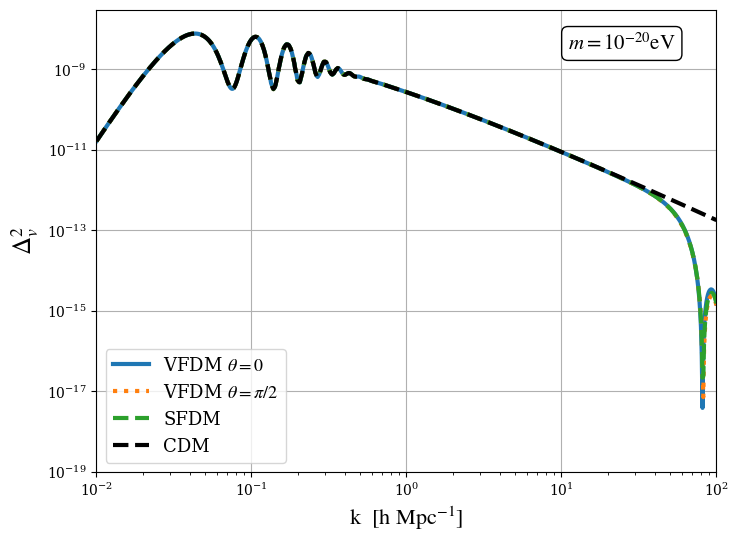

In [6]:
# m = 10^{-20} eV — VFDM (TF) vs SFDM vs CDM

invariant_scf = np.load('../../SFDM_data/Velocity_invariant_SFDM/invariant_sf_m=%s.npz' % (str(mass)[-3:]))['arr_1']

plt.figure(figsize=(8, 6))
plt.grid()
plt.ylabel(r'$\Delta_{v}^2$', size=18, family='STIXGeneral')
plt.xlabel(r'k  [h $\mathrm{Mpc}^{-1}$]', size=16, family='STIXGeneral')

plt.plot(k_out, inv_vf0(k_out),                                   label=r'VFDM $\theta=0$',   lw=3)
plt.plot(k_out, inv_vfpi2(k_out),                                 label=r'VFDM $\theta=\pi/2$', lw=3, linestyle=':')
plt.plot(k_out, invariant_scf,    color='tab:green', linestyle='dashed', label='SFDM',                 lw=3)
plt.plot(k_out, inv_lcdm(k_out),  color='black',      linestyle='dashed', label='CDM',                  lw=3)

plt.xscale('log')
plt.yscale('log')
plt.legend(loc='lower left', fontsize=13)
plt.ylim(1.e-19, 3*1.e-8)
plt.xlim(1.e-2, 1.e2)
plt.text(11, 3*1.e-9, r'$m = 10^{%s} \rm{eV}$' % (str(mass)[-3:]),
         bbox=dict(facecolor='white', boxstyle='round', alpha=1), size=15)
plt.savefig('../../Figures/Invariant_%s_transfer.pdf' % (str(mass)[-3:]), format='pdf')
plt.show()


### $m = 10^{-21} \rm{eV}$ — transfer function approach

In [7]:
mass    = 1.e-21
k_max_h = 100.
k_out   = np.logspace(-2, np.log10(k_max_h), 800)

inv_vf0   = velocity_invariant_from_tf(compute_transfer_vfdm(mass, 0,        k_max_h), 't_vf')
inv_vfpi2 = velocity_invariant_from_tf(compute_transfer_vfdm(mass, np.pi/2, k_max_h), 't_vf')
inv_lcdm  = velocity_invariant_from_tf(compute_transfer_lcdm(k_max_h),                None)


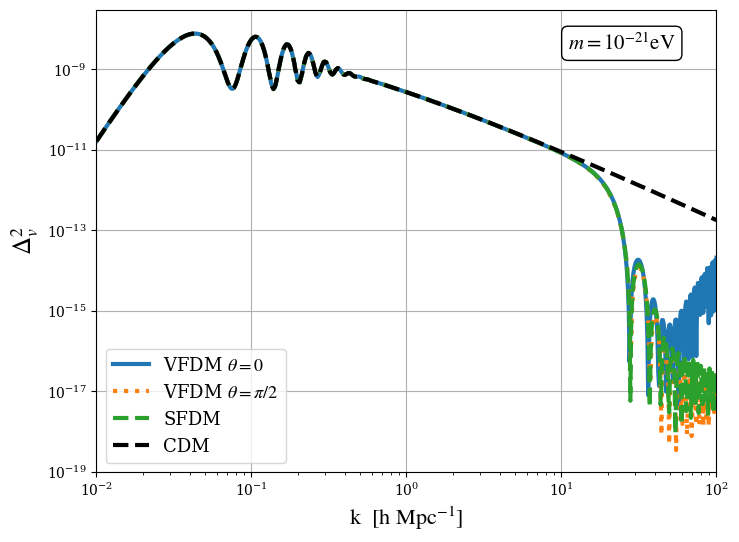

In [8]:
# m = 10^{-21} eV — VFDM (TF) vs SFDM vs CDM

invariant_scf = np.load('../../SFDM_data/Velocity_invariant_SFDM/invariant_sf_m=%s.npz' % (str(mass)[-3:]))['arr_1']

plt.figure(figsize=(8, 6))
plt.grid()
plt.ylabel(r'$\Delta_{v}^2$', size=18, family='STIXGeneral')
plt.xlabel(r'k  [h $\mathrm{Mpc}^{-1}$]', size=16, family='STIXGeneral')

plt.plot(k_out, inv_vf0(k_out),                                   label=r'VFDM $\theta=0$',   lw=3)
plt.plot(k_out, inv_vfpi2(k_out),                                 label=r'VFDM $\theta=\pi/2$', lw=3, linestyle=':')
plt.plot(k_out, invariant_scf,    color='tab:green', linestyle='dashed', label='SFDM',                 lw=3)
plt.plot(k_out, inv_lcdm(k_out),  color='black',      linestyle='dashed', label='CDM',                  lw=3)

plt.xscale('log')
plt.yscale('log')
plt.legend(loc='lower left', fontsize=13)
plt.ylim(1.e-19, 3*1.e-8)
plt.xlim(1.e-2, 1.e2)
plt.text(11, 3*1.e-9, r'$m = 10^{%s} \rm{eV}$' % (str(mass)[-3:]),
         bbox=dict(facecolor='white', boxstyle='round', alpha=1), size=15)
plt.savefig('../../Figures/Invariant_%s_transfer.pdf' % (str(mass)[-3:]), format='pdf')
plt.show()


### $m = 10^{-22} \rm{eV}$ — transfer function approach

In [9]:
mass    = 1.e-22
k_max_h = 100.
k_out   = np.logspace(-2, np.log10(k_max_h), 800)

inv_vf0   = velocity_invariant_from_tf(compute_transfer_vfdm(mass, 0,        k_max_h), 't_vf')
inv_vfpi2 = velocity_invariant_from_tf(compute_transfer_vfdm(mass, np.pi/2, k_max_h), 't_vf')
inv_lcdm  = velocity_invariant_from_tf(compute_transfer_lcdm(k_max_h),                None)


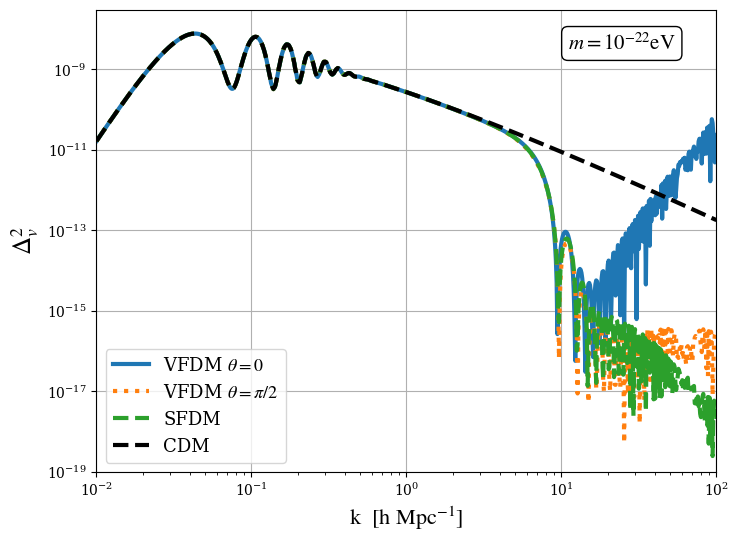

In [10]:
# m = 10^{-22} eV — VFDM (TF) vs SFDM vs CDM

invariant_scf = np.load('../../SFDM_data/Velocity_invariant_SFDM/invariant_sf_m=%s.npz' % (str(mass)[-3:]))['arr_1']

plt.figure(figsize=(8, 6))
plt.grid()
plt.ylabel(r'$\Delta_{v}^2$', size=18, family='STIXGeneral')
plt.xlabel(r'k  [h $\mathrm{Mpc}^{-1}$]', size=16, family='STIXGeneral')

plt.plot(k_out, inv_vf0(k_out),                                   label=r'VFDM $\theta=0$',   lw=3)
plt.plot(k_out, inv_vfpi2(k_out),                                 label=r'VFDM $\theta=\pi/2$', lw=3, linestyle=':')
plt.plot(k_out, invariant_scf,    color='tab:green', linestyle='dashed', label='SFDM',                 lw=3)
plt.plot(k_out, inv_lcdm(k_out),  color='black',      linestyle='dashed', label='CDM',                  lw=3)

plt.xscale('log')
plt.yscale('log')
plt.legend(loc='lower left', fontsize=13)
plt.ylim(1.e-19, 3*1.e-8)
plt.xlim(1.e-2, 1.e2)
plt.text(11, 3*1.e-9, r'$m = 10^{%s} \rm{eV}$' % (str(mass)[-3:]),
         bbox=dict(facecolor='white', boxstyle='round', alpha=1), size=15)
plt.savefig('../../Figures/Invariant_%s_transfer.pdf' % (str(mass)[-3:]), format='pdf')
plt.show()


### $m = 10^{-23} \rm{eV}$ — transfer function approach

In [11]:
mass    = 1.e-23
k_max_h = 50.
k_out   = np.logspace(-2, np.log10(k_max_h), 800)

inv_vf0   = velocity_invariant_from_tf(compute_transfer_vfdm(mass, 0,        k_max_h), 't_vf')
inv_vfpi2 = velocity_invariant_from_tf(compute_transfer_vfdm(mass, np.pi/2, k_max_h), 't_vf')
inv_lcdm  = velocity_invariant_from_tf(compute_transfer_lcdm(k_max_h),                None)


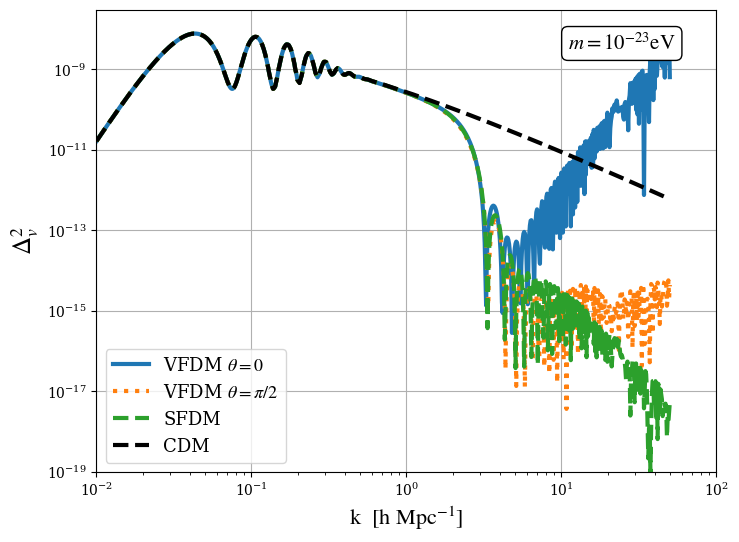

In [12]:
# m = 10^{-23} eV — VFDM (TF) vs SFDM vs CDM

invariant_scf = np.load('../../SFDM_data/Velocity_invariant_SFDM/invariant_sf_m=%s.npz' % (str(mass)[-3:]))['arr_1']

plt.figure(figsize=(8, 6))
plt.grid()
plt.ylabel(r'$\Delta_{v}^2$', size=18, family='STIXGeneral')
plt.xlabel(r'k  [h $\mathrm{Mpc}^{-1}$]', size=16, family='STIXGeneral')

plt.plot(k_out, inv_vf0(k_out),                                   label=r'VFDM $\theta=0$',   lw=3)
plt.plot(k_out, inv_vfpi2(k_out),                                 label=r'VFDM $\theta=\pi/2$', lw=3, linestyle=':')
plt.plot(k_out, invariant_scf,    color='tab:green', linestyle='dashed', label='SFDM',                 lw=3)
plt.plot(k_out, inv_lcdm(k_out),  color='black',      linestyle='dashed', label='CDM',                  lw=3)

plt.xscale('log')
plt.yscale('log')
plt.legend(loc='lower left', fontsize=13)
plt.ylim(1.e-19, 3*1.e-8)
plt.xlim(1.e-2, 1.e2)
plt.text(11, 3*1.e-9, r'$m = 10^{%s} \rm{eV}$' % (str(mass)[-3:]),
         bbox=dict(facecolor='white', boxstyle='round', alpha=1), size=15)
plt.savefig('../../Figures/Invariant_%s_transfer.pdf' % (str(mass)[-3:]), format='pdf')
plt.show()


### $m = 10^{-24} \rm{eV}$ — transfer function approach

In [5]:
mass    = 1.e-24
k_max_h = 10.
k_out   = np.logspace(-2, np.log10(k_max_h), 800)

inv_vf0   = velocity_invariant_from_tf(compute_transfer_vfdm(mass, 0,        k_max_h), 't_vf')
inv_vfpi2 = velocity_invariant_from_tf(compute_transfer_vfdm(mass, np.pi/2, k_max_h), 't_vf')
inv_lcdm  = velocity_invariant_from_tf(compute_transfer_lcdm(k_max_h),                None)


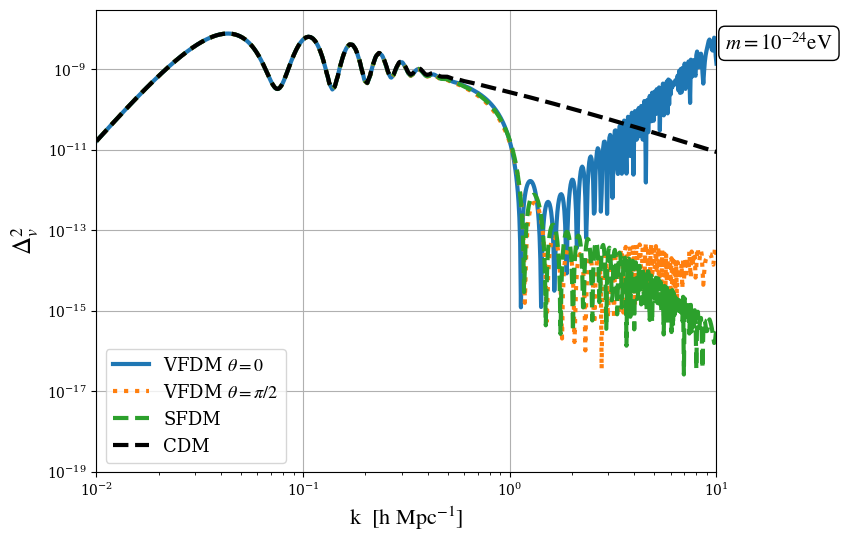

In [6]:
# m = 10^{-24} eV — VFDM (TF) vs SFDM vs CDM

invariant_scf = np.load('../../SFDM_data/Velocity_invariant_SFDM/invariant_sf_m=%s.npz' % (str(mass)[-3:]))['arr_1']

plt.figure(figsize=(8, 6))
plt.grid()
plt.ylabel(r'$\Delta_{v}^2$', size=18, family='STIXGeneral')
plt.xlabel(r'k  [h $\mathrm{Mpc}^{-1}$]', size=16, family='STIXGeneral')

plt.plot(k_out, inv_vf0(k_out),                                   label=r'VFDM $\theta=0$',   lw=3)
plt.plot(k_out, inv_vfpi2(k_out),                                 label=r'VFDM $\theta=\pi/2$', lw=3, linestyle=':')
plt.plot(k_out, invariant_scf,    color='tab:green', linestyle='dashed', label='SFDM',                 lw=3)
plt.plot(k_out, inv_lcdm(k_out),  color='black',      linestyle='dashed', label='CDM',                  lw=3)

plt.xscale('log')
plt.yscale('log')
plt.legend(loc='lower left', fontsize=13)
plt.ylim(1.e-19, 3*1.e-8)
plt.xlim(1.e-2, k_max_h)
plt.text(11, 3*1.e-9, r'$m = 10^{%s} \rm{eV}$' % (str(mass)[-3:]),
         bbox=dict(facecolor='white', boxstyle='round', alpha=1), size=15)
plt.savefig('../../Figures/Invariant_%s_transfer.pdf' % (str(mass)[-3:]), format='pdf')
plt.show()


### $m = 10^{-25} \rm{eV}$ — transfer function approach

In [15]:
mass    = 1.e-25
k_max_h = 10.
k_out   = np.logspace(-2, np.log10(k_max_h), 800)

inv_vf0   = velocity_invariant_from_tf(compute_transfer_vfdm(mass, 0,        k_max_h), 't_vf')
inv_vfpi2 = velocity_invariant_from_tf(compute_transfer_vfdm(mass, np.pi/2, k_max_h), 't_vf')
inv_lcdm  = velocity_invariant_from_tf(compute_transfer_lcdm(k_max_h),                None)


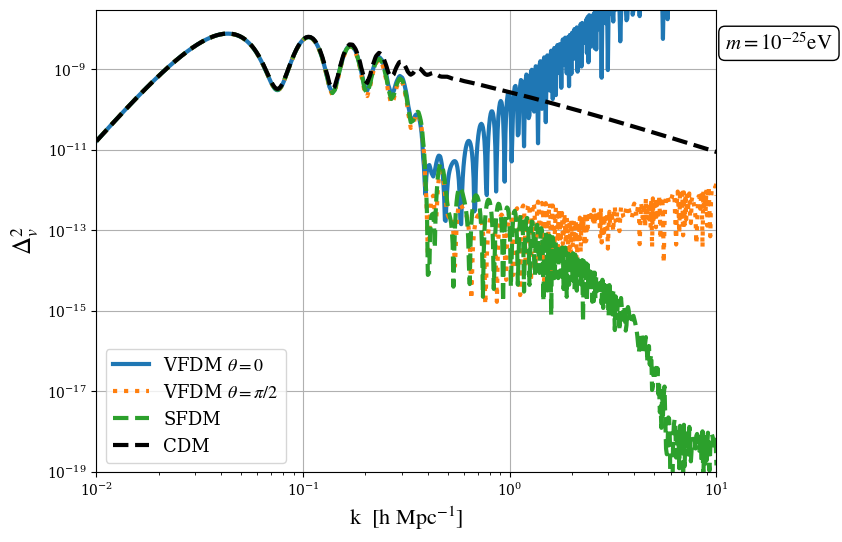

In [16]:
# m = 10^{-25} eV — VFDM (TF) vs SFDM vs CDM

invariant_scf = np.load('../../SFDM_data/Velocity_invariant_SFDM/invariant_sf_m=%s.npz' % (str(mass)[-3:]))['arr_1']

plt.figure(figsize=(8, 6))
plt.grid()
plt.ylabel(r'$\Delta_{v}^2$', size=18, family='STIXGeneral')
plt.xlabel(r'k  [h $\mathrm{Mpc}^{-1}$]', size=16, family='STIXGeneral')

plt.plot(k_out, inv_vf0(k_out),                                   label=r'VFDM $\theta=0$',   lw=3)
plt.plot(k_out, inv_vfpi2(k_out),                                 label=r'VFDM $\theta=\pi/2$', lw=3, linestyle=':')
plt.plot(k_out, invariant_scf,    color='tab:green', linestyle='dashed', label='SFDM',                 lw=3)
plt.plot(k_out, inv_lcdm(k_out),  color='black',      linestyle='dashed', label='CDM',                  lw=3)

plt.xscale('log')
plt.yscale('log')
plt.legend(loc='lower left', fontsize=13)
plt.ylim(1.e-19, 3*1.e-8)
plt.xlim(1.e-2, k_max_h)
plt.text(11, 3*1.e-9, r'$m = 10^{%s} \rm{eV}$' % (str(mass)[-3:]),
         bbox=dict(facecolor='white', boxstyle='round', alpha=1), size=15)
plt.savefig('../../Figures/Invariant_%s_transfer.pdf' % (str(mass)[-3:]), format='pdf')
plt.show()
